# Deep Leakage from Gradients — Batch Attack (Section 3.2)
Implementação da estratégia de atualização por amostra individual descrita na Seção 3.2 do paper.

In [50]:
%matplotlib inline
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
from torchvision import datasets, transforms
from random import randint

print(torch.__version__, torchvision.__version__)

2.10.0+cpu 0.25.0+cpu


In [51]:
# ============ CONFIGURAÇÃO ============
BATCH_SIZE = 2        # Número de imagens no batch original
NUM_ITERS  = 500  # Mais iterações para batch > 1 (paper sugere ~600 para BS=2)
SEED = 50
torch.manual_seed(SEED)
num_classes = 100

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Running on', device)

Running on cpu


In [52]:
# Dataset e transforms
dst = datasets.CIFAR100('~/.torch', download=True)
tp = transforms.Compose([transforms.Resize(32), transforms.CenterCrop(32), transforms.ToTensor()])
tt = transforms.ToPILImage()

def label_to_onehot(target, num_classes=100):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target

def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(-target * F.log_softmax(pred, dim=-1), 1))

In [53]:
# Modelo
def weights_init(m):
    if hasattr(m, 'weight'): m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, 'bias'):   m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=1), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=1), act(),
        )
        self.fc = nn.Sequential(nn.Linear(768, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)

net = LeNet().to(device)
net.apply(weights_init)
criterion = cross_entropy_for_onehot

def tv_loss(img):
    # img: tensor de shape (batch, canais, altura, largura)
    return torch.sum(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1])) + \
           torch.sum(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))

# Escolha manual de Imagens

In [54]:
# indices_desejados = [80, 54]   # deve ter tamanho igual a BATCH_SIZE

# for idx in indices_desejados:
#     gt_images.append(tp(dst[idx][0]))
#     gt_labels.append(dst[idx][1])

#Escolha Aleatoria de Imagens

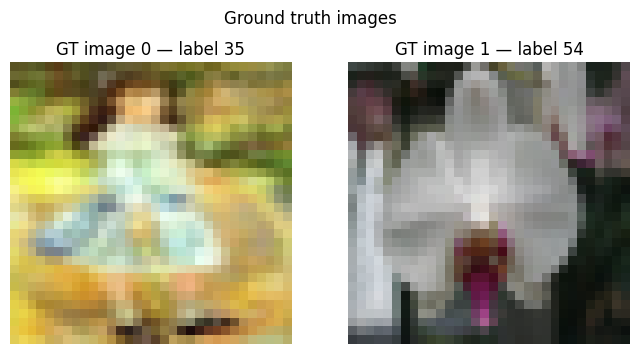

In [55]:
# ============ PARTICIPANTE HONESTO: batch de BATCH_SIZE imagens ============

gt_images = []
gt_labels = []
for _ in range(BATCH_SIZE):
    idx = randint(0, len(dst) - 1)
    gt_images.append(tp(dst[idx][0]))
    gt_labels.append(dst[idx][1])
gt_data = torch.stack(gt_images).to(device)                       # [N, 3, 32, 32]
gt_label = torch.tensor(gt_labels, dtype=torch.long, device=device)  # [N]
gt_onehot_label = label_to_onehot(gt_label, num_classes=num_classes) # [N, C]

# Visualizar
fig, axes = plt.subplots(1, BATCH_SIZE, figsize=(4*BATCH_SIZE, 4))
if BATCH_SIZE == 1: axes = [axes]
for i in range(BATCH_SIZE):
    axes[i].imshow(tt(gt_data[i].cpu()))
    axes[i].set_title(f'GT image {i} — label {gt_label[i].item()}')
    axes[i].axis('off')
plt.suptitle('Ground truth images')
plt.show()

# Gradientes reais do batch completo
out = net(gt_data)
y = criterion(out, gt_onehot_label)
dy_dx = torch.autograd.grad(y, net.parameters())
original_dy_dx = list(_.detach().clone() for _ in dy_dx)

In [56]:
# ============ ATAQUE DLG — Seção 3.2: atualizar uma amostra por vez ============
#
# Em vez de otimizar todo o batch dummy de uma vez (o que não converge),
# atualizamos apenas a amostra (i mod N) a cada iteração.
# Isso equivale a congelar as outras amostras e só otimizar uma.

# Inicializar dummy data e labels (todo o batch)
dummy_data = torch.rand(gt_data.size(), device=device, requires_grad=True)   # uniforme [0,1]
dummy_label = torch.randn(gt_onehot_label.size(), device=device, requires_grad=True)

history = [[] for _ in range(BATCH_SIZE)]  # histórico por imagem
loss_history = []

for iters in range(NUM_ITERS):
    # Determinar qual amostra atualizar nesta iteração
    target_idx = iters % BATCH_SIZE

    # Criar otimizador LBFGS apenas para a amostra target_idx.
    # Precisamos de tensores independentes para controlar quais têm grad.
    # Estratégia: reconstruir dummy_data/dummy_label a cada iteração
    # mantendo apenas a fatia target_idx como otimizável.

    # Separar a fatia alvo (com grad) das outras (sem grad)
    slices_data  = []
    slices_label = []
    opt_data  = dummy_data[target_idx:target_idx+1].detach().clone().requires_grad_(True)
    opt_label = dummy_label[target_idx:target_idx+1].detach().clone().requires_grad_(True)

    optimizer = torch.optim.LBFGS([opt_data, opt_label], lr=1.0)

    def closure():
        optimizer.zero_grad()
        # Montar o batch completo, inserindo a fatia otimizável na posição certa
        parts_data  = []
        parts_label = []
        for j in range(BATCH_SIZE):
            if j == target_idx:
                parts_data.append(opt_data)
                parts_label.append(F.softmax(opt_label, dim=-1))
            else:
                parts_data.append(dummy_data[j:j+1].detach())  # congelado
                parts_label.append(F.softmax(dummy_label[j:j+1].detach(), dim=-1))

        batch_data  = torch.cat(parts_data,  dim=0)
        batch_label = torch.cat(parts_label, dim=0)

        pred = net(batch_data)
        dummy_loss = criterion(pred, batch_label)
        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = sum(((gx - gy) ** 2).sum() for gx, gy in zip(dummy_dy_dx, original_dy_dx))
        loss = grad_diff + 0.0001 * tv_loss(batch_data)   # ajuste o coeficiente conforme necessário
        # MUITO IMPORTANTE o coeficiente do tv_loss
        loss.backward()
        return grad_diff

    optimizer.step(closure)

    # Escrever de volta no tensor principal
    with torch.no_grad():
        dummy_data[target_idx]  = opt_data[0].detach()
        dummy_label[target_idx] = opt_label[0].detach()

    # Logging
    if iters % 10 == 0:
        current_loss = closure().item()
        loss_history.append(current_loss)
        print(f'iter {iters:4d}  |  updating sample {target_idx}  |  loss {current_loss:.4f}')

    for j in range(BATCH_SIZE):
        history[j].append(tt(dummy_data[j].detach().cpu()))

iter    0  |  updating sample 0  |  loss 88.4317
iter   10  |  updating sample 0  |  loss 2.1590
iter   20  |  updating sample 0  |  loss 0.8215
iter   30  |  updating sample 0  |  loss 0.4318
iter   40  |  updating sample 0  |  loss 0.2742
iter   50  |  updating sample 0  |  loss 0.1959
iter   60  |  updating sample 0  |  loss 0.1483
iter   70  |  updating sample 0  |  loss 0.1170
iter   80  |  updating sample 0  |  loss 0.0937
iter   90  |  updating sample 0  |  loss 0.0768
iter  100  |  updating sample 0  |  loss 0.0637
iter  110  |  updating sample 0  |  loss 0.0532
iter  120  |  updating sample 0  |  loss 0.0448
iter  130  |  updating sample 0  |  loss 0.0380
iter  140  |  updating sample 0  |  loss 0.0323
iter  150  |  updating sample 0  |  loss 0.0276
iter  160  |  updating sample 0  |  loss 0.0239
iter  170  |  updating sample 0  |  loss 0.0208
iter  180  |  updating sample 0  |  loss 0.0183
iter  190  |  updating sample 0  |  loss 0.0163
iter  200  |  updating sample 0  |  los

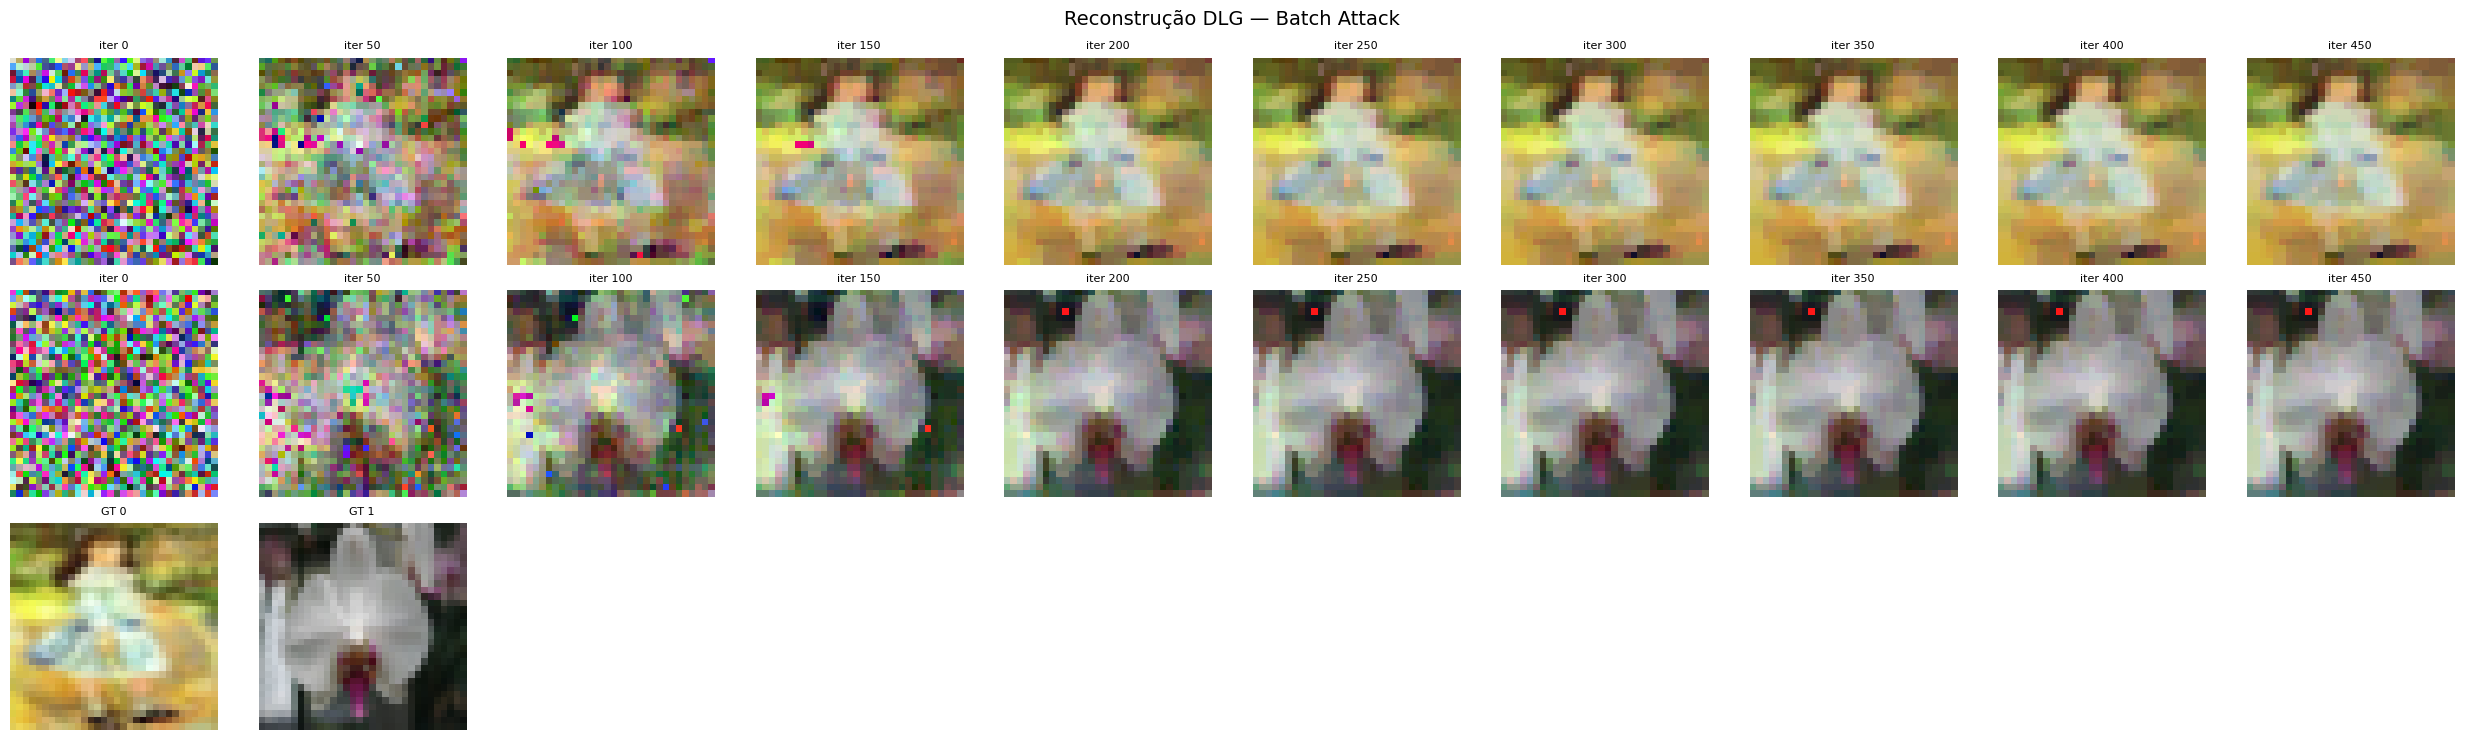

Imagem 0: label predito = 35, label real = 35
Imagem 1: label predito = 54, label real = 54


In [57]:
# ============ VISUALIZAÇÃO ============
n_snapshots = 10
step = max(1, len(history[0]) // n_snapshots)

fig, axes = plt.subplots(BATCH_SIZE + 1, n_snapshots, figsize=(2.5 * n_snapshots, 2.5 * (BATCH_SIZE + 1)))
if BATCH_SIZE + 1 == 1:
    axes = [axes]

for img_idx in range(BATCH_SIZE):
    for col, snap in enumerate(range(0, len(history[img_idx]), step)):
        if col >= n_snapshots:
            break
        axes[img_idx][col].imshow(history[img_idx][snap])
        axes[img_idx][col].set_title(f'iter {snap}', fontsize=8)
        axes[img_idx][col].axis('off')
    axes[img_idx][0].set_ylabel(f'Img {img_idx}', fontsize=10)

# Última linha: ground truth
for i in range(n_snapshots):
    axes[BATCH_SIZE][i].axis('off')
for i in range(BATCH_SIZE):
    if i < n_snapshots:
        axes[BATCH_SIZE][i].imshow(tt(gt_data[i].cpu()))
        axes[BATCH_SIZE][i].set_title(f'GT {i}', fontsize=8)
        axes[BATCH_SIZE][i].axis('off')
axes[BATCH_SIZE][0].set_ylabel('Ground\nTruth', fontsize=10)

plt.suptitle('Reconstrução DLG — Batch Attack', fontsize=14)
plt.tight_layout()
plt.show()

# Labels reconstruídos
for i in range(BATCH_SIZE):
    pred_label = torch.argmax(dummy_label[i]).item()
    true_label = gt_label[i].item()
    print(f'Imagem {i}: label predito = {pred_label}, label real = {true_label}')

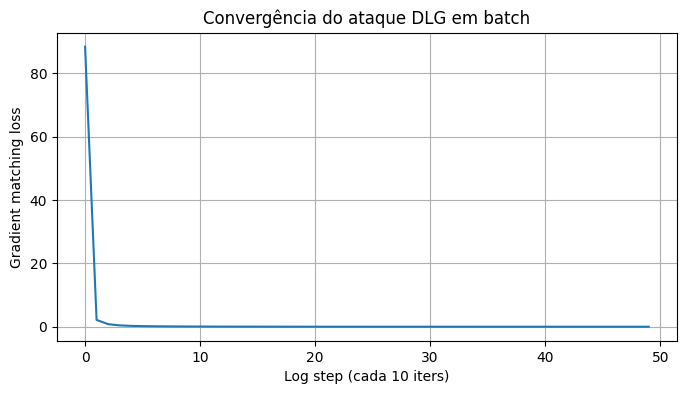

In [58]:
# Curva de loss
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel('Log step (cada 10 iters)')
plt.ylabel('Gradient matching loss')
plt.title('Convergência do ataque DLG em batch')
plt.grid(True)
plt.show()